# Exploratory Data Analysis (EDA)

## Context

Bob has started his own mobile company. He wants to give tough fight to big companies like Apple,Samsung etc.

He does not know how to estimate price of mobiles his company creates. In this competitive mobile phone market you cannot simply assume things. To solve this problem he collects sales data of mobile phones of various companies.

Bob wants to find out some relation between features of a mobile phone(eg:- RAM,Internal Memory etc) and its selling price. But he is not so good at Machine Learning. So he needs your help to solve this problem.

In this problem you do not have to predict actual price but a price range indicating how high the price is


## Завантаження бібліотек

In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Завантаження даних

In [18]:
df = pd.read_csv("data/train.csv")

In [19]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


## Початковий аналіз та обробка даних 
(перевірка на пропущені значення, типи фічерів, їх початкова обробка для подальшого аналізу)

In [20]:
# Перевірка розміру датасету
# 891 рядок та 12 стовпців
df.shape

(2000, 21)

In [21]:
# Перевірка на наявність пропущених значень
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [22]:
# Дивимось на кількість унікальних значень кожного фічера в датасеті
#  Це допоможе нам визначити, які фічери можна використовувати для моделювання    
df.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

In [23]:
# Дивимось на типи даних кожного фічера 
# (object часто означає категоріальний фічер у форматі string, який треба буде обробити)
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

## Побудова графіків для аналізу даних

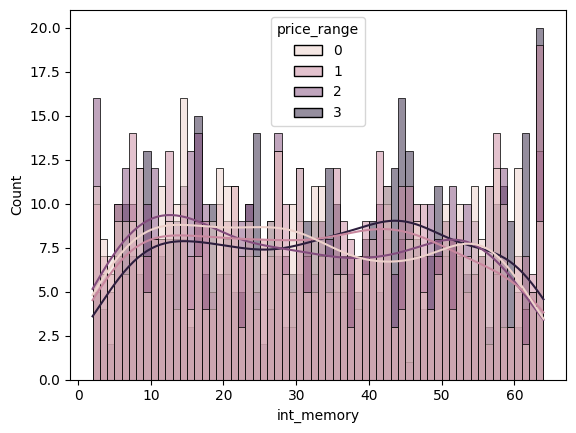

In [25]:
sns.histplot(data=df, x='int_memory', hue='price_range', binwidth=1, kde=True)
plt.show()

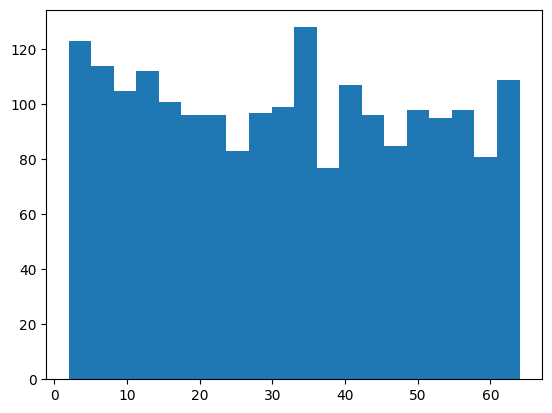

In [28]:
plt.hist(df["int_memory"], bins=20)
plt.show()

#### Побудова кореляційної матриці фічерів

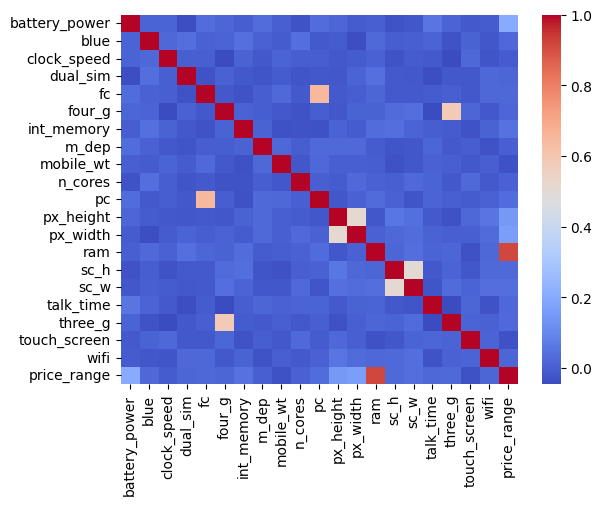

In [31]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## Розділ даних

In [32]:
x = df.drop(columns=["price_range"])
y = df["price_range"]

### Спосіб 1: train/val/test split

In [33]:
x_train, x_val_test, y_train, y_val_test = train_test_split(x, y, test_size=0.4, random_state=42)

In [34]:
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=42)

In [35]:
x_train.shape, x_val.shape, x_test.shape

((1200, 20), (400, 20), (400, 20))

In [37]:
x_train.to_csv("data/processed_data/x_train.csv", index=False)
x_val.to_csv("data/processed_data/x_val.csv", index=False)
x_test.to_csv("data/processed_data/x_test.csv", index=False)

y_train.to_csv("data/processed_data/y_train.csv", index=False)
y_val.to_csv("data/processed_data/y_val.csv", index=False)
y_test.to_csv("data/processed_data/y_test.csv", index=False)

### Спосіб 2: Cross-validation

In [57]:
kf = KFold(n_splits=4)

In [58]:
c = 1
for train, test in kf.split(x, y):
    print(c)
    c += 1
    print(train.shape)
    print(test.shape)

1
(688,)
(230,)
2
(688,)
(230,)
3
(689,)
(229,)
4
(689,)
(229,)


In [59]:
df.to_csv("data/cv_data/features.csv", index=False)
df.to_csv("data/cv_data/target.csv", index=False)